## RRT* + Stanley Controller + SLAM

1. **RRT*** global path on known map
2. **Stanley Controller**: heading error + cross-track error correction
3. Moving obstacle avoidance + live SLAM

In [1]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
import os, sys
sys.path.append('../../')
from utils.mujoco_parser import MuJoCoParserClass
from utils.util import r2rpy
from utils.rrt import RapidlyExploringRandomTreesStarClass
np.set_printoptions(precision=2, suppress=True, linewidth=100)
plt.rc('xtick', labelsize=6); plt.rc('ytick', labelsize=6)
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
print("MuJoCo version:[%s]" % (mujoco.__version__))

import mujoco_viewer
def _patched_add_marker_to_scene(self, marker):
    if self.scn.ngeom >= self.scn.maxgeom: return
    g = self.scn.geoms[self.scn.ngeom]
    g.dataid=-1; g.objtype=mujoco.mjtObj.mjOBJ_UNKNOWN; g.objid=-1
    g.category=mujoco.mjtCatBit.mjCAT_DECOR
    g.emission=0; g.specular=0.5; g.shininess=0.5; g.reflectance=0
    g.type=mujoco.mjtGeom.mjGEOM_BOX; g.size[:]=np.ones(3)*0.1
    g.mat[:]=np.eye(3); g.rgba[:]=np.ones(4)
    for key,value in marker.items():
        if isinstance(value,(int,float,mujoco._enums.mjtGeom)): setattr(g,key,value)
        elif isinstance(value,(tuple,list,np.ndarray)):
            attr=getattr(g,key); attr[:]=np.asarray(value).flat[:len(attr)]
        elif isinstance(value,str): setattr(g,key,value)
    self.scn.ngeom += 1
mujoco_viewer.MujocoViewer._add_marker_to_scene = _patched_add_marker_to_scene

MuJoCo version:[3.8.1]


### Maze + Moving Obstacles

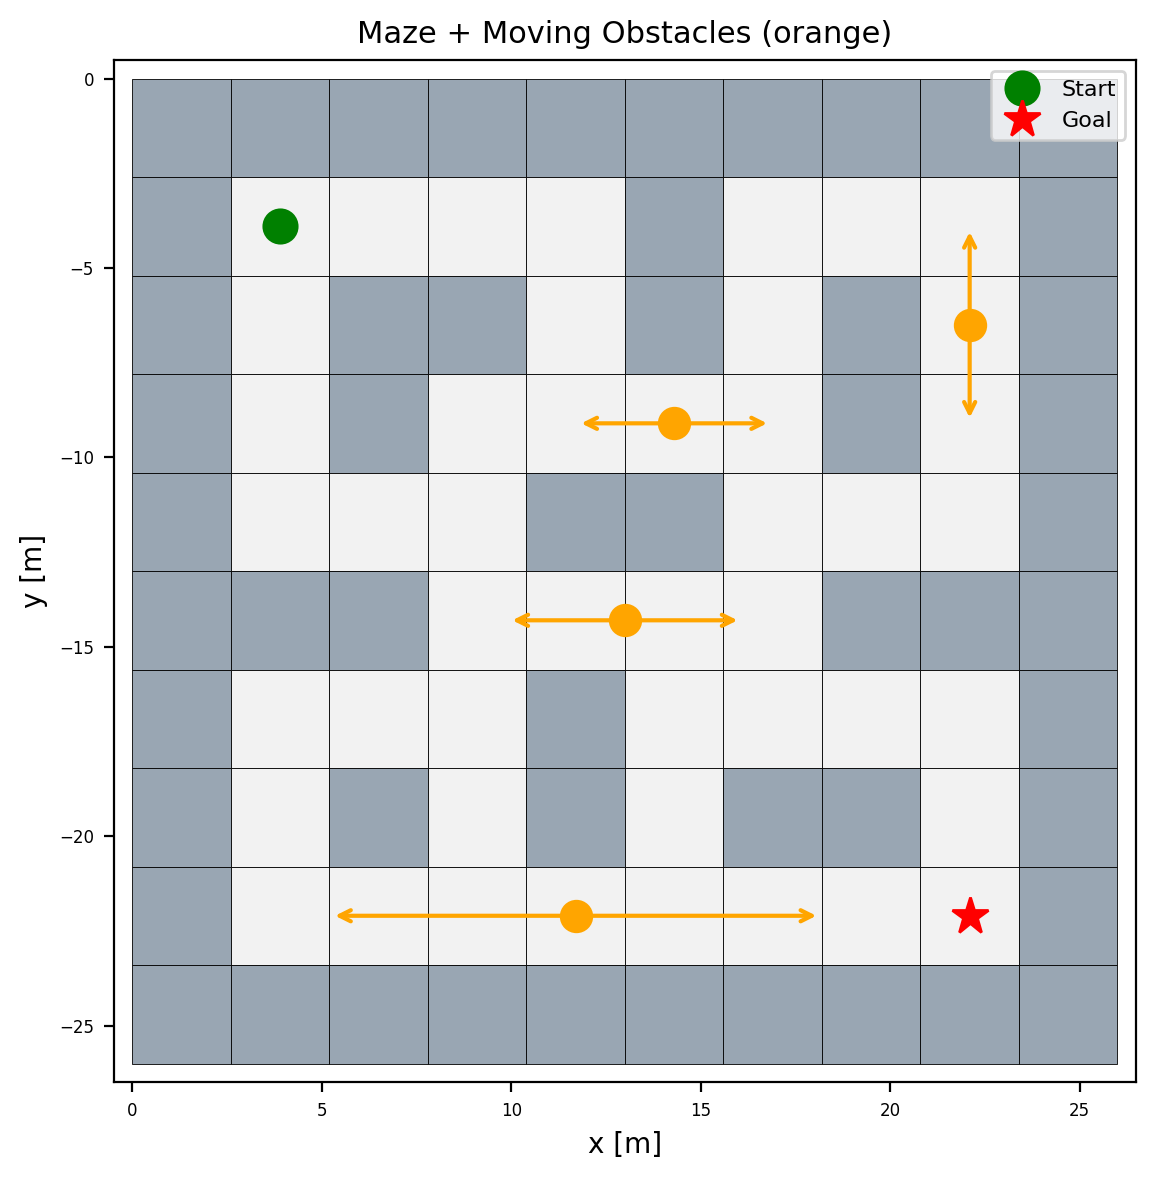

Start: (3.9,-3.9), Goal: (22.1,-22.1)
Moving obstacles: 4


In [2]:
MAZE_MAP = np.array([
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 0, 1, 1, 0, 1, 0, 1, 0, 1],
    [1, 0, 1, 0, 0, 0, 0, 1, 0, 1],
    [1, 0, 0, 0, 1, 1, 0, 0, 0, 1],
    [1, 1, 1, 0, 0, 0, 0, 1, 1, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 1],
    [1, 0, 1, 0, 1, 0, 1, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
])
CELL_SIZE = 2.6; WALL_HEIGHT = 1.0
START_CELL = (1, 1); GOAL_CELL = (8, 8)
n_rows, n_cols = MAZE_MAP.shape

def cell_to_world(row, col):
    return col * CELL_SIZE + CELL_SIZE / 2, -(row * CELL_SIZE + CELL_SIZE / 2)

# Moving obstacles: (row, col, axis, amplitude_cells, freq_hz, phase)
MOVING_OBS = [
    (3, 5,   'x', 1.0,  0.08, 0.0),  # row 3 corridor
    (5, 4.5, 'x', 1.2,  0.06, 1.5),  # row 5 corridor
    (8, 4,   'x', 2.5,  0.05, 3.0),  # row 8 long corridor
    (2, 8,   'y', 1.0,  0.07, 0.7),  # col 8 vertical
]

def generate_maze_xml_with_obs(maze_map, cell_size, wall_height, obs_list, xml_dir):
    n_rows, n_cols = maze_map.shape
    walls = []
    for r in range(n_rows):
        for c in range(n_cols):
            if maze_map[r, c] == 1:
                x, y = cell_to_world(r, c)
                walls.append(f'    <geom name="wall_{len(walls)}" type="box" '
                    f'pos="{x:.3f} {y:.3f} {wall_height/2:.3f}" '
                    f'size="{cell_size/2:.3f} {cell_size/2:.3f} {wall_height/2:.3f}" '
                    f'rgba="0.6 0.65 0.7 1" contype="1" conaffinity="1"/>')
    obs_bodies = []
    for i, (r, c, axis, amp, freq, phase) in enumerate(obs_list):
        x, y = cell_to_world(r, c)
        obs_bodies.append(
            f'    <body name="obs_{i}" mocap="true" pos="{x:.3f} {y:.3f} 0.5">\n'
            f'      <geom name="obs_geom_{i}" type="cylinder" size="0.25 0.5" '
            f'rgba="1.0 0.4 0.0 0.85" contype="1" conaffinity="1"/>\n'
            f'    </body>')
    xml = ('<mujoco model="husky maze">\n'
           '  <include file="./husky_w_lidar.xml"/>\n'
           '  <include file="../object/floor_sky.xml"/>\n'
           '  <worldbody>\n'
           + '\n'.join(walls) + '\n'
           + '\n'.join(obs_bodies) + '\n'
           '  </worldbody>\n'
           '</mujoco>\n')
    p = os.path.join(xml_dir, 'scene_husky_maze_slam.xml')
    with open(p, 'w') as f: f.write(xml)
    return p

generate_maze_xml_with_obs(MAZE_MAP, CELL_SIZE, WALL_HEIGHT, MOVING_OBS,
                           os.path.abspath('../../asset/husky'))
start_x, start_y = cell_to_world(*START_CELL)
goal_x, goal_y = cell_to_world(*GOAL_CELL)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
for r in range(n_rows):
    for c in range(n_cols):
        wx, wy = cell_to_world(r, c)
        color = [0.6,0.65,0.7] if MAZE_MAP[r,c]==1 else [0.95,0.95,0.95]
        ax.add_patch(plt.Rectangle((wx-CELL_SIZE/2, wy-CELL_SIZE/2),
            CELL_SIZE, CELL_SIZE, fc=color, ec='k', lw=0.3))
for i, (r, c, axis, amp, freq, phase) in enumerate(MOVING_OBS):
    ox, oy = cell_to_world(r, c)
    ax.plot(ox, oy, 'o', color='orange', ms=10, mew=2, mfc='orange')
    if axis == 'x':
        ax.annotate('', xy=(ox+amp*CELL_SIZE, oy), xytext=(ox-amp*CELL_SIZE, oy),
                    arrowprops=dict(arrowstyle='<->', color='orange', lw=1.5))
    else:
        ax.annotate('', xy=(ox, oy+amp*CELL_SIZE), xytext=(ox, oy-amp*CELL_SIZE),
                    arrowprops=dict(arrowstyle='<->', color='orange', lw=1.5))
ax.plot(start_x, start_y, 'go', ms=12, label='Start')
ax.plot(goal_x, goal_y, 'r*', ms=14, label='Goal')
ax.set_xlim(-0.5, n_cols*CELL_SIZE+0.5); ax.set_ylim(-(n_rows*CELL_SIZE+0.5), 0.5)
ax.set_aspect('equal'); ax.legend(fontsize=8)
ax.set_title('Maze + Moving Obstacles (orange)', fontsize=11)
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
plt.tight_layout(); plt.show()
print(f"Start: ({start_x:.1f},{start_y:.1f}), Goal: ({goal_x:.1f},{goal_y:.1f})")
print(f"Moving obstacles: {len(MOVING_OBS)}")

### Load Scene + Helpers

In [3]:
env = MuJoCoParserClass(name='Husky', rel_xml_path='../../asset/husky/scene_husky_maze_slam.xml', VERBOSE=True)

N_LIDAR_RAYS = 72; LIDAR_MAX_RANGE = 10.0
wheel_radius = 0.17775 / 2.0; wheel_base = 0.2854 * 2
N_MOCAP = env.model.nmocap
print(f"Mocap bodies (moving obstacles): {N_MOCAP}")

# Precompute obstacle motion parameters in world coords
obs_centers = []
obs_axes = []    # 0=x, 1=y
obs_amps = []
obs_freqs = []
obs_phases = []
for r, c, axis, amp, freq, phase in MOVING_OBS:
    cx, cy = cell_to_world(r, c)
    obs_centers.append([cx, cy, 0.5])
    obs_axes.append(0 if axis == 'x' else 1)
    obs_amps.append(amp * CELL_SIZE)
    obs_freqs.append(freq)
    obs_phases.append(phase)

def update_obstacles(env, t):
    """Move mocap obstacles with sinusoidal motion."""
    for i in range(N_MOCAP):
        pos = np.array(obs_centers[i])
        offset = obs_amps[i] * np.sin(2*np.pi*obs_freqs[i]*t + obs_phases[i])
        pos[obs_axes[i]] += offset
        env.data.mocap_pos[i] = pos

def get_lidar_scan(env, n_rays=72, max_range=10.0):
    ranges = np.zeros(n_rays)
    for i in range(n_rays):
        val = env.get_sensor_value(f'lidar_{i:03d}')[0]
        ranges[i] = val if val >= 0 else max_range
    return ranges

def lidar_to_world_points(ranges, rx, ry, yaw, n_rays=72):
    a = np.linspace(0, 2*np.pi, n_rays, endpoint=False) + yaw
    return rx + ranges*np.cos(a), ry + ranges*np.sin(a)

def render_lidar(env, p, yaw, ranges, n_rays=72, max_range=10.0):
    hx, hy = lidar_to_world_points(ranges, p[0], p[1], yaw, n_rays)
    mask = ranges < max_range - 0.1; z = 0.65
    idxs = np.where(mask)[0]
    if len(idxs) < 2: return
    for k in range(len(idxs)):
        i0, i1 = idxs[k], idxs[(k+1) % len(idxs)]
        if abs(i1-i0) <= 2 or abs(i1-i0) >= n_rays-2:
            p0 = np.array([hx[i0], hy[i0], z]); p1 = np.array([hx[i1], hy[i1], z])
            env.plot_cylinder_fr2to(p_fr=p0, p_to=p1, r=0.07, rgba=[1.0, 0.4, 0.15, 0.15])
            env.plot_cylinder_fr2to(p_fr=p0, p_to=p1, r=0.025, rgba=[1.0, 0.3, 0.05, 0.4])

dt:[0.0020] HZ:[500]
n_dof (=nv):[10]
n_geom:[69]
geom_names:['floor', 'wall_0', 'wall_1', 'wall_2', 'wall_3', 'wall_4', 'wall_5', 'wall_6', 'wall_7', 'wall_8', 'wall_9', 'wall_10', 'wall_11', 'wall_12', 'wall_13', 'wall_14', 'wall_15', 'wall_16', 'wall_17', 'wall_18', 'wall_19', 'wall_20', 'wall_21', 'wall_22', 'wall_23', 'wall_24', 'wall_25', 'wall_26', 'wall_27', 'wall_28', 'wall_29', 'wall_30', 'wall_31', 'wall_32', 'wall_33', 'wall_34', 'wall_35', 'wall_36', 'wall_37', 'wall_38', 'wall_39', 'wall_40', 'wall_41', 'wall_42', 'wall_43', 'wall_44', 'wall_45', 'wall_46', 'wall_47', 'wall_48', 'wall_49', 'wall_50', 'wall_51', 'wall_52', 'wall_53', None, None, None, None, None, None, None, None, None, None, 'obs_geom_0', 'obs_geom_1', 'obs_geom_2', 'obs_geom_3']
n_body:[10]
body_names:['world', 'base_husky', 'front_left_wheel_link', 'front_right_wheel_link', 'rear_left_wheel_link', 'rear_right_wheel_link', 'obs_0', 'obs_1', 'obs_2', 'obs_3']
n_joint:[5]
joint_names:['base_husky_joint', '

### RRT* on Known Map (static obstacles only)

The RRT* plans on the static wall map. Moving obstacles are handled reactively during navigation.

In [4]:
class OccupancyGrid:
    def __init__(self, x_range, y_range, resolution=0.1):
        self.resolution = resolution
        self.x_min, self.x_max = x_range; self.y_min, self.y_max = y_range
        self.width = int(np.ceil((self.x_max-self.x_min)/resolution))
        self.height = int(np.ceil((self.y_max-self.y_min)/resolution))
        self.log_odds = np.zeros((self.height, self.width), dtype=np.float32)
        self.l_occ=0.7; self.l_free=-0.4; self.l_max=5.0; self.l_min=-5.0

    def world_to_grid(self, x, y):
        gx=int((x-self.x_min)/self.resolution); gy=int((y-self.y_min)/self.resolution)
        return np.clip(gx,0,self.width-1), np.clip(gy,0,self.height-1)

    def bresenham(self, x0, y0, x1, y1):
        cells=[]; dx,dy=abs(x1-x0),abs(y1-y0)
        sx=1 if x0<x1 else -1; sy=1 if y0<y1 else -1; err=dx-dy
        while True:
            cells.append((x0,y0))
            if x0==x1 and y0==y1: break
            e2=2*err
            if e2>-dy: err-=dy; x0+=sx
            if e2<dx: err+=dx; y0+=sy
        return cells

    def update(self, rx, ry, yaw, ranges, n_rays=72, max_range=10.0):
        gx0,gy0=self.world_to_grid(rx,ry); angles=np.linspace(0,2*np.pi,n_rays,endpoint=False)
        for i in range(n_rays):
            a=angles[i]+yaw; r=ranges[i]; hit=r<max_range-0.1
            ex,ey=self.world_to_grid(rx+r*np.cos(a),ry+r*np.sin(a))
            for cx,cy in self.bresenham(gx0,gy0,ex,ey)[:-1]:
                if 0<=cx<self.width and 0<=cy<self.height: self.log_odds[cy,cx]+=self.l_free
            if hit and 0<=ex<self.width and 0<=ey<self.height: self.log_odds[ey,ex]+=self.l_occ
        np.clip(self.log_odds,self.l_min,self.l_max,out=self.log_odds)

    def get_map_image(self):
        return 1.0-1.0/(1.0+np.exp(self.log_odds))

    def is_free(self, x, y, margin=0.3):
        gx,gy=self.world_to_grid(x,y); r=int(margin/self.resolution)
        for dx in range(-r,r+1):
            for dy in range(-r,r+1):
                cx,cy=gx+dx,gy+dy
                if not(0<=cx<self.width and 0<=cy<self.height): return False
                if self.log_odds[cy,cx]>=0.0: return False
        return True

    def is_line_free(self, x1, y1, x2, y2, margin=0.3):
        r=int(margin/self.resolution)
        for cx,cy in self.bresenham(*self.world_to_grid(x1,y1),*self.world_to_grid(x2,y2)):
            for ddx in range(-r,r+1):
                for ddy in range(-r,r+1):
                    nx_,ny_=cx+ddx,cy+ddy
                    if not(0<=nx_<self.width and 0<=ny_<self.height): return False
                    if self.log_odds[ny_,nx_]>=0.0: return False
        return True

margin = 2.0
known_og = OccupancyGrid(x_range=(-margin, n_cols*CELL_SIZE+margin),
                          y_range=(-(n_rows*CELL_SIZE+margin), margin), resolution=0.1)
for r in range(n_rows):
    for c in range(n_cols):
        wx,wy = cell_to_world(r,c); gx,gy = known_og.world_to_grid(wx,wy)
        half = int(CELL_SIZE/2/known_og.resolution)
        for dx in range(-half,half+1):
            for dy in range(-half,half+1):
                cx,cy = gx+dx,gy+dy
                if 0<=cx<known_og.width and 0<=cy<known_og.height:
                    known_og.log_odds[cy,cx] = known_og.l_max if MAZE_MAP[r,c]==1 else known_og.l_min
print(f"Known map: {known_og.width}x{known_og.height}")

robot_xy = np.array([start_x, start_y]); goal_xy = np.array([goal_x, goal_y])
rrt = RapidlyExploringRandomTreesStarClass(
    name='RRT', point_min=np.array([known_og.x_min+0.5,known_og.y_min+0.5]),
    point_max=np.array([known_og.x_max-0.5,known_og.y_max-0.5]),
    goal_select_rate=0.15, steer_len_max=1.0, search_radius=2.0,
    n_node_max=5000, SPEED_UP=True)
rrt.init_rrt_star(point_root=robot_xy, point_goal=goal_xy, seed=42)
N_ITER=3000; goal_reached=False
for it in range(N_ITER):
    ps = goal_xy.copy() if np.random.rand()<rrt.goal_select_rate else rrt.sample_point()
    if not known_og.is_free(ps[0],ps[1]): continue
    nn=rrt.get_node_nearest(ps); pt,cs=rrt.steer(nn,ps)
    if pt is None or not known_og.is_free(pt[0],pt[1]): continue
    pn=rrt.get_node_point(nn)
    if not known_og.is_line_free(pn[0],pn[1],pt[0],pt[1]): continue
    near=rrt.get_nodes_near(pt); nb_,cb_=nn,cs
    for nr in near:
        p_nr=rrt.get_node_point(nr); c_nr=rrt.get_node_cost(nr)+rrt.get_dist(p_nr,pt)
        if c_nr<cb_ and known_og.is_line_free(p_nr[0],p_nr[1],pt[0],pt[1]): nb_,cb_=nr,c_nr
    n_new=rrt.add_node(point=pt,cost=cb_,node_parent=nb_)
    for nr in near:
        if nr==nb_: continue
        p_nr=rrt.get_node_point(nr); c_new=cb_+rrt.get_dist(pt,p_nr)
        if c_new<rrt.get_node_cost(nr) and known_og.is_line_free(pt[0],pt[1],p_nr[0],p_nr[1]):
            rrt.replace_node_parent(nr,n_new); rrt.update_node_info(nr,cost=c_new)
    if rrt.get_dist(pt,goal_xy)<rrt.steer_len_max and known_og.is_line_free(pt[0],pt[1],goal_xy[0],goal_xy[1]):
        cg=cb_+rrt.get_dist(pt,goal_xy); eg=rrt.get_node_goal(eps=0.05)
        if eg is None or cg<rrt.get_node_cost(eg):
            rrt.add_node(point=goal_xy.copy(),cost=cg,node_parent=n_new)
            if not goal_reached: print(f"  Goal at iter {it}, cost={cg:.2f}"); goal_reached=True
    if (it+1)%500==0: print(f"  Iter {it+1}/{N_ITER}, nodes={rrt.get_n_node()}, goal={goal_reached}")
path_to_goal,_=rrt.get_path_to_goal()
if path_to_goal is not None:
    print(f"Path: {len(path_to_goal)} waypoints, cost={rrt.get_cost_goal():.2f}m")
else:
    print("No path found.")

Known map: 300x300
  Goal at iter 416, cost=29.79
  Iter 500/3000, nodes=119, goal=True
  Iter 1500/3000, nodes=406, goal=True
Path: 21 waypoints, cost=29.57m


### RRT* Path Visualization

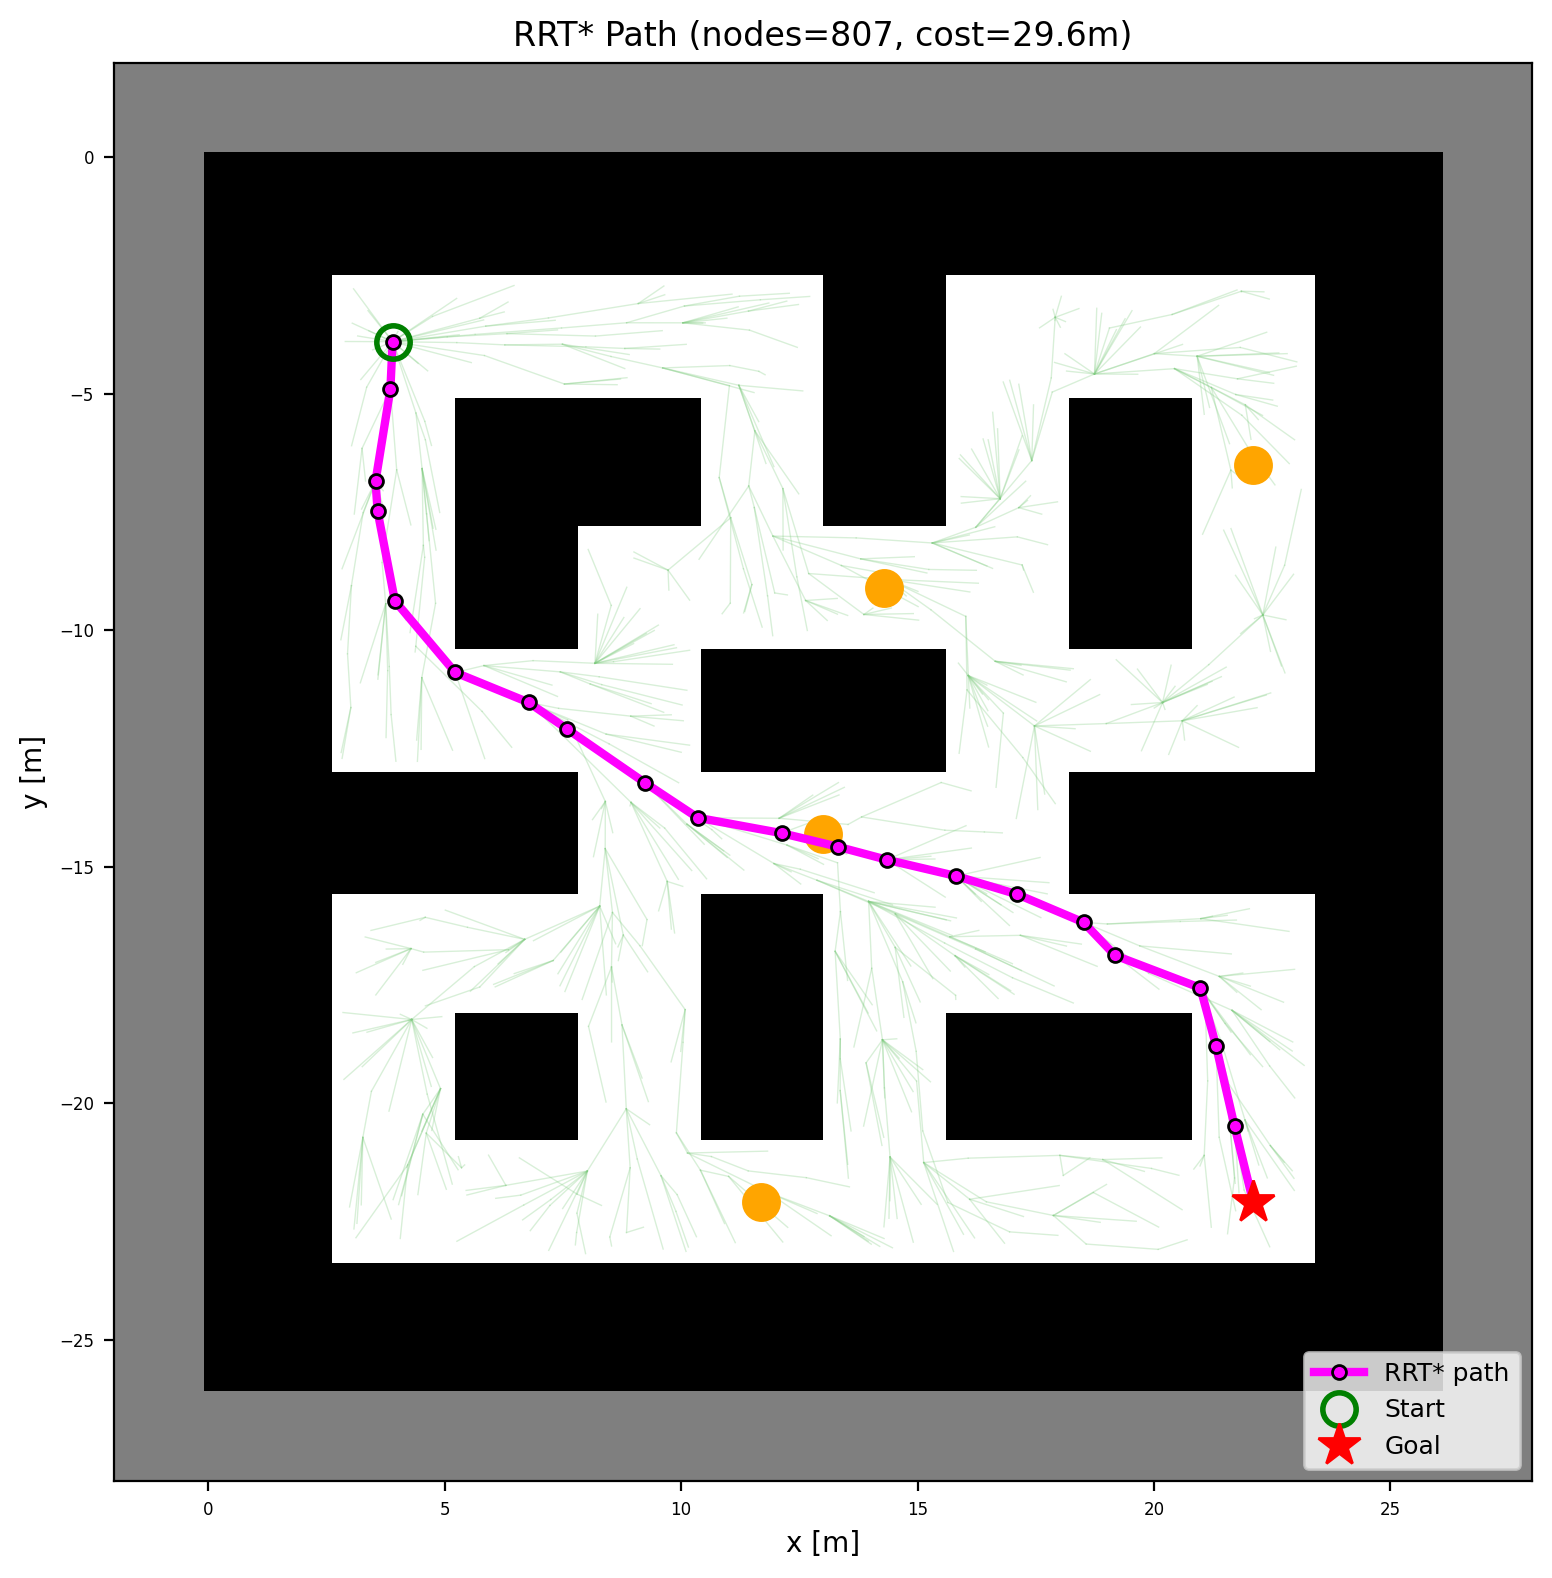

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
known_img = known_og.get_map_image()
ax.imshow(known_img, cmap='gray_r', origin='lower',
          extent=[known_og.x_min, known_og.x_max, known_og.y_min, known_og.y_max])
pos = {n: rrt.get_node_point(n) for n in rrt.get_nodes()}
for (n1, n2) in rrt.get_edges():
    p1, p2 = pos[n1], pos[n2]
    ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '-', color=[0.5,0.8,0.5,0.3], lw=0.5)
if path_to_goal is not None:
    ax.plot(path_to_goal[:,0], path_to_goal[:,1], 'o-', color='magenta',
            lw=3, ms=5, mec='k', mfc='magenta', label='RRT* path', zorder=5)
# Obstacle centers
for r, c, axis, amp, freq, phase in MOVING_OBS:
    ox, oy = cell_to_world(r, c)
    ax.plot(ox, oy, 'o', color='orange', ms=12, mew=2, mfc='orange', zorder=4)
ax.plot(start_x, start_y, 'go', ms=12, mew=2, mfc='none', label='Start', zorder=6)
ax.plot(goal_x, goal_y, 'r*', ms=16, label='Goal', zorder=6)
cost_str = f'{rrt.get_cost_goal():.1f}' if path_to_goal is not None else 'N/A'
ax.set_title(f'RRT* Path (nodes={rrt.get_n_node()}, cost={cost_str}m)')
ax.set_aspect('equal'); ax.legend(fontsize=9, loc='lower right')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')
plt.tight_layout(); plt.show()

### Stanley Controller

In [6]:
def stanley_controller(p_robot, yaw, path, prev_ci=0, v_des=0.7, k_e=3.0, k_h=1.5):
    """Stanley controller: heading error + cross-track error correction."""
    xy = p_robot[:2]
    ci = prev_ci
    while ci < len(path) - 1:
        if np.linalg.norm(path[ci+1] - xy) < np.linalg.norm(path[ci] - xy):
            ci += 1
        else:
            break
    if ci < len(path) - 1:
        tangent = path[ci+1] - path[ci]
    else:
        tangent = path[ci] - path[max(ci-1, 0)]
    path_yaw = np.arctan2(tangent[1], tangent[0])
    # Heading error
    psi_e = path_yaw - yaw
    psi_e = (psi_e + np.pi) % (2*np.pi) - np.pi
    # Cross-track error (positive = robot LEFT of path)
    d = xy - path[ci]
    e = -d[0]*np.sin(path_yaw) + d[1]*np.cos(path_yaw)
    # Speed
    v = v_des * np.clip(np.cos(psi_e), 0.1, 1.0)
    # Stanley law
    w = k_h * psi_e + np.arctan2(k_e * e, max(v, 0.1))
    w = np.clip(w, -3.0, 3.0)
    return v, w, ci

### Stanley Controller Navigation + Live SLAM

In [7]:
assert path_to_goal is not None, "No path. Re-run RRT*."

slam_og = OccupancyGrid(x_range=(-margin, n_cols*CELL_SIZE+margin),
                         y_range=(-(n_rows*CELL_SIZE+margin), margin), resolution=0.1)

env.data.qpos[:] = 0; env.data.qvel[:] = 0; env.data.ctrl[:] = 0
env.data.qpos[0]=start_x; env.data.qpos[1]=start_y; env.data.qpos[2]=0.1
env.data.qpos[3:7]=[1,0,0,0]
env.tick = 0; env.render_tick = 0
mujoco.mj_forward(env.model, env.data)

env.init_viewer(viewer_title='Navigation', viewer_width=1200, viewer_height=800,
                viewer_hide_menus=True)
env.update_viewer(azimuth=90, distance=25, elevation=-75,
                  lookat=[n_cols*CELL_SIZE/2, -n_rows*CELL_SIZE/2, 0.0])

V_DES=0.7; GOAL_TOL=0.5
trajectory=[]; prev_ci=1
ranges = get_lidar_scan(env, N_LIDAR_RAYS, LIDAR_MAX_RANGE)

while env.is_viewer_alive():
    t = env.get_sim_time()
    p = env.get_p_body('base_husky')
    yaw = r2rpy(env.get_R_body('base_husky'))[2]
    update_obstacles(env, t)

    if env.loop_every(HZ=5) or (env.tick==1):
        ranges = get_lidar_scan(env, N_LIDAR_RAYS, LIDAR_MAX_RANGE)
        slam_og.update(p[0], p[1], yaw, ranges, N_LIDAR_RAYS, LIDAR_MAX_RANGE)

    if np.linalg.norm(p[:2]-np.array([goal_x,goal_y])) < GOAL_TOL:
        print(f"Goal reached at t={t:.1f}s!")
        for _ in range(500):
            update_obstacles(env, env.get_sim_time())
            env.step(ctrl=np.zeros(4), ctrl_idxs=[0,1,2,3])
            if env.loop_every(HZ=30):
                env.plot_sphere(p=np.array([goal_x,goal_y,0.5]),r=0.3,rgba=[0,1,0,0.8],label='REACHED!')
                env.render()
        break

    # Local planner
    v, w, prev_ci = stanley_controller(p, yaw, path_to_goal, prev_ci=prev_ci, v_des=V_DES)

    # Obstacle avoidance
    front_idxs = list(range(0,7)) + list(range(65,72))
    front_dist = np.min(ranges[front_idxs])
    if front_dist < 0.5:
        v *= 0.2
        ld = np.min(ranges[11:25]); rd = np.min(ranges[49:61])
        w += 1.5 * (1.0 if ld > rd else -1.0)
    elif front_dist < 1.0:
        v *= (front_dist - 0.5) / 0.5

    vl = v-(w*wheel_base/2); vr = v+(w*wheel_base/2)
    ctrl = np.array([vl,vr,vl,vr], dtype=np.float32) / wheel_radius
    np.clip(ctrl, -20, 20, out=ctrl)
    env.step(ctrl=ctrl, ctrl_idxs=[0,1,2,3])
    trajectory.append([p[0],p[1]])

    if env.loop_every(HZ=30) or (env.tick==1):
        render_lidar(env, p, yaw, ranges, N_LIDAR_RAYS, LIDAR_MAX_RANGE)
        for k in range(len(path_to_goal)-1):
            env.plot_cylinder_fr2to(
                p_fr=np.array([path_to_goal[k,0],path_to_goal[k,1],0.3]),
                p_to=np.array([path_to_goal[k+1,0],path_to_goal[k+1,1],0.3]),
                r=0.03, rgba=[1,0,1,0.4])
        env.plot_sphere(p=np.array([goal_x,goal_y,0.5]),r=0.2,rgba=[1,0,0,0.8],label='GOAL')
        env.plot_body_T(body_name='base_husky',PLOT_AXIS=True,axis_len=0.3,axis_width=0.02)
        env.plot_T(p=p+np.array([0,0,1]),R=np.eye(3),PLOT_AXIS=False,
                   label='t=%.1fs ci=%d/%d'%(t,prev_ci,len(path_to_goal)))
        env.render()

env.close_viewer()
trajectory = np.array(trajectory)
print(f"Done. {len(trajectory)} steps, {env.get_sim_time():.1f}s")

Pressed ESC
Quitting.
Done. 2945 steps, 5.9s


2026-06-14 21:28:50.889 python[44439:75948444] TSM AdjustCapsLockLEDForKeyTransitionHandling - _ISSetPhysicalKeyboardCapsLockLED Inhibit


### Result: SLAM Map + Trajectory

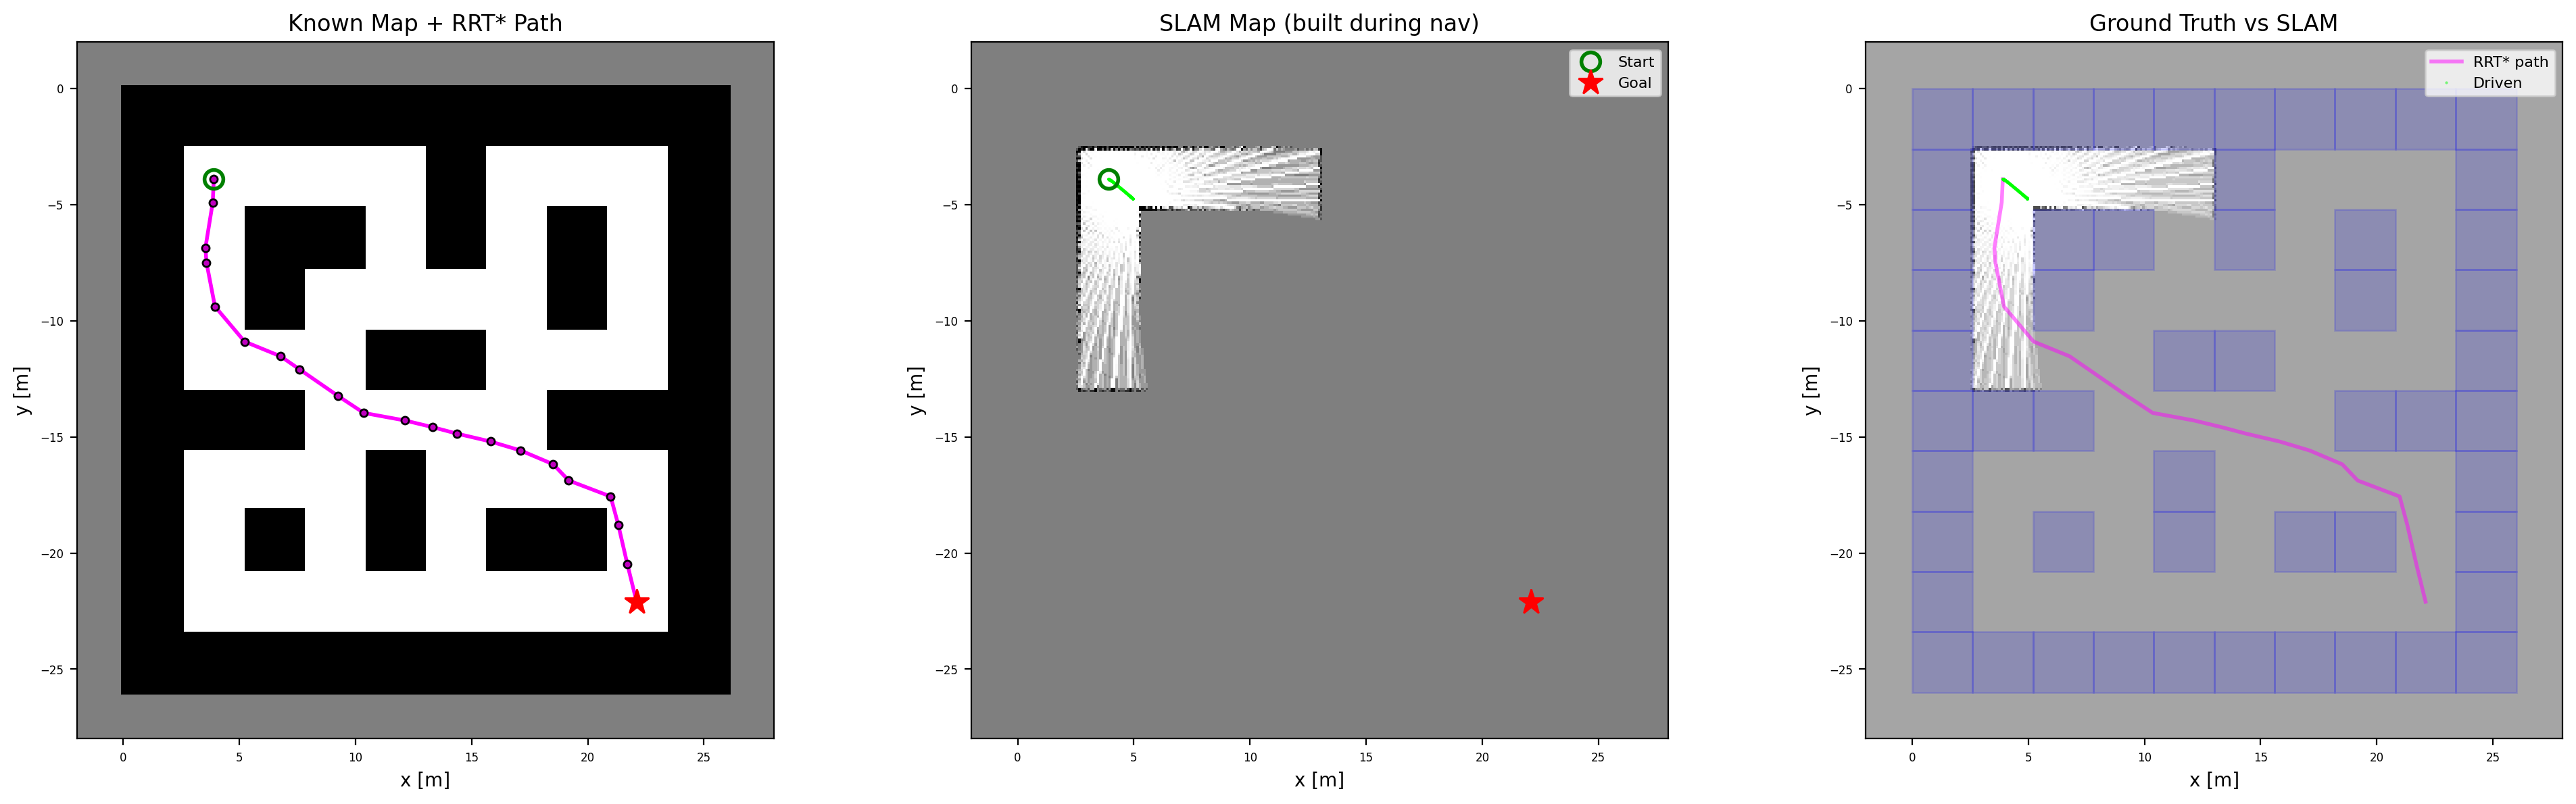

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

ax = axes[0]
ax.imshow(known_img, cmap='gray_r', origin='lower',
          extent=[known_og.x_min,known_og.x_max,known_og.y_min,known_og.y_max])
ax.plot(path_to_goal[:,0], path_to_goal[:,1], 'o-', color='magenta', lw=2, ms=4, mec='k', mfc='m')
ax.plot(start_x, start_y, 'go', ms=10, mew=2, mfc='none')
ax.plot(goal_x, goal_y, 'r*', ms=14)
ax.set_title('Known Map + RRT* Path'); ax.set_aspect('equal')
ax.set_xlabel('x [m]'); ax.set_ylabel('y [m]')

ax2 = axes[1]
slam_img = slam_og.get_map_image()
ax2.imshow(slam_img, cmap='gray_r', origin='lower',
           extent=[slam_og.x_min,slam_og.x_max,slam_og.y_min,slam_og.y_max])
if len(trajectory)>0:
    ax2.plot(trajectory[::5,0], trajectory[::5,1], '.', color='lime', ms=1, alpha=0.5)
ax2.plot(start_x, start_y, 'go', ms=10, mew=2, mfc='none', label='Start')
ax2.plot(goal_x, goal_y, 'r*', ms=14, label='Goal')
ax2.set_title('SLAM Map (built during nav)'); ax2.set_aspect('equal'); ax2.legend(fontsize=8)
ax2.set_xlabel('x [m]'); ax2.set_ylabel('y [m]')

ax3 = axes[2]
for r in range(n_rows):
    for c in range(n_cols):
        if MAZE_MAP[r,c]==1:
            wx,wy = cell_to_world(r,c)
            ax3.add_patch(plt.Rectangle((wx-CELL_SIZE/2,wy-CELL_SIZE/2),
                CELL_SIZE,CELL_SIZE,lw=1,ec='blue',fc='blue',alpha=0.15))
ax3.imshow(slam_img, cmap='gray_r', origin='lower', alpha=0.7,
           extent=[slam_og.x_min,slam_og.x_max,slam_og.y_min,slam_og.y_max])
ax3.plot(path_to_goal[:,0], path_to_goal[:,1], '-', color='magenta', lw=2, alpha=0.5, label='RRT* path')
if len(trajectory)>0:
    ax3.plot(trajectory[::5,0], trajectory[::5,1], '.', color='lime', ms=1, alpha=0.5, label='Driven')
ax3.set_title('Ground Truth vs SLAM'); ax3.set_aspect('equal'); ax3.legend(fontsize=8)
ax3.set_xlabel('x [m]'); ax3.set_ylabel('y [m]')
plt.tight_layout(); plt.show()